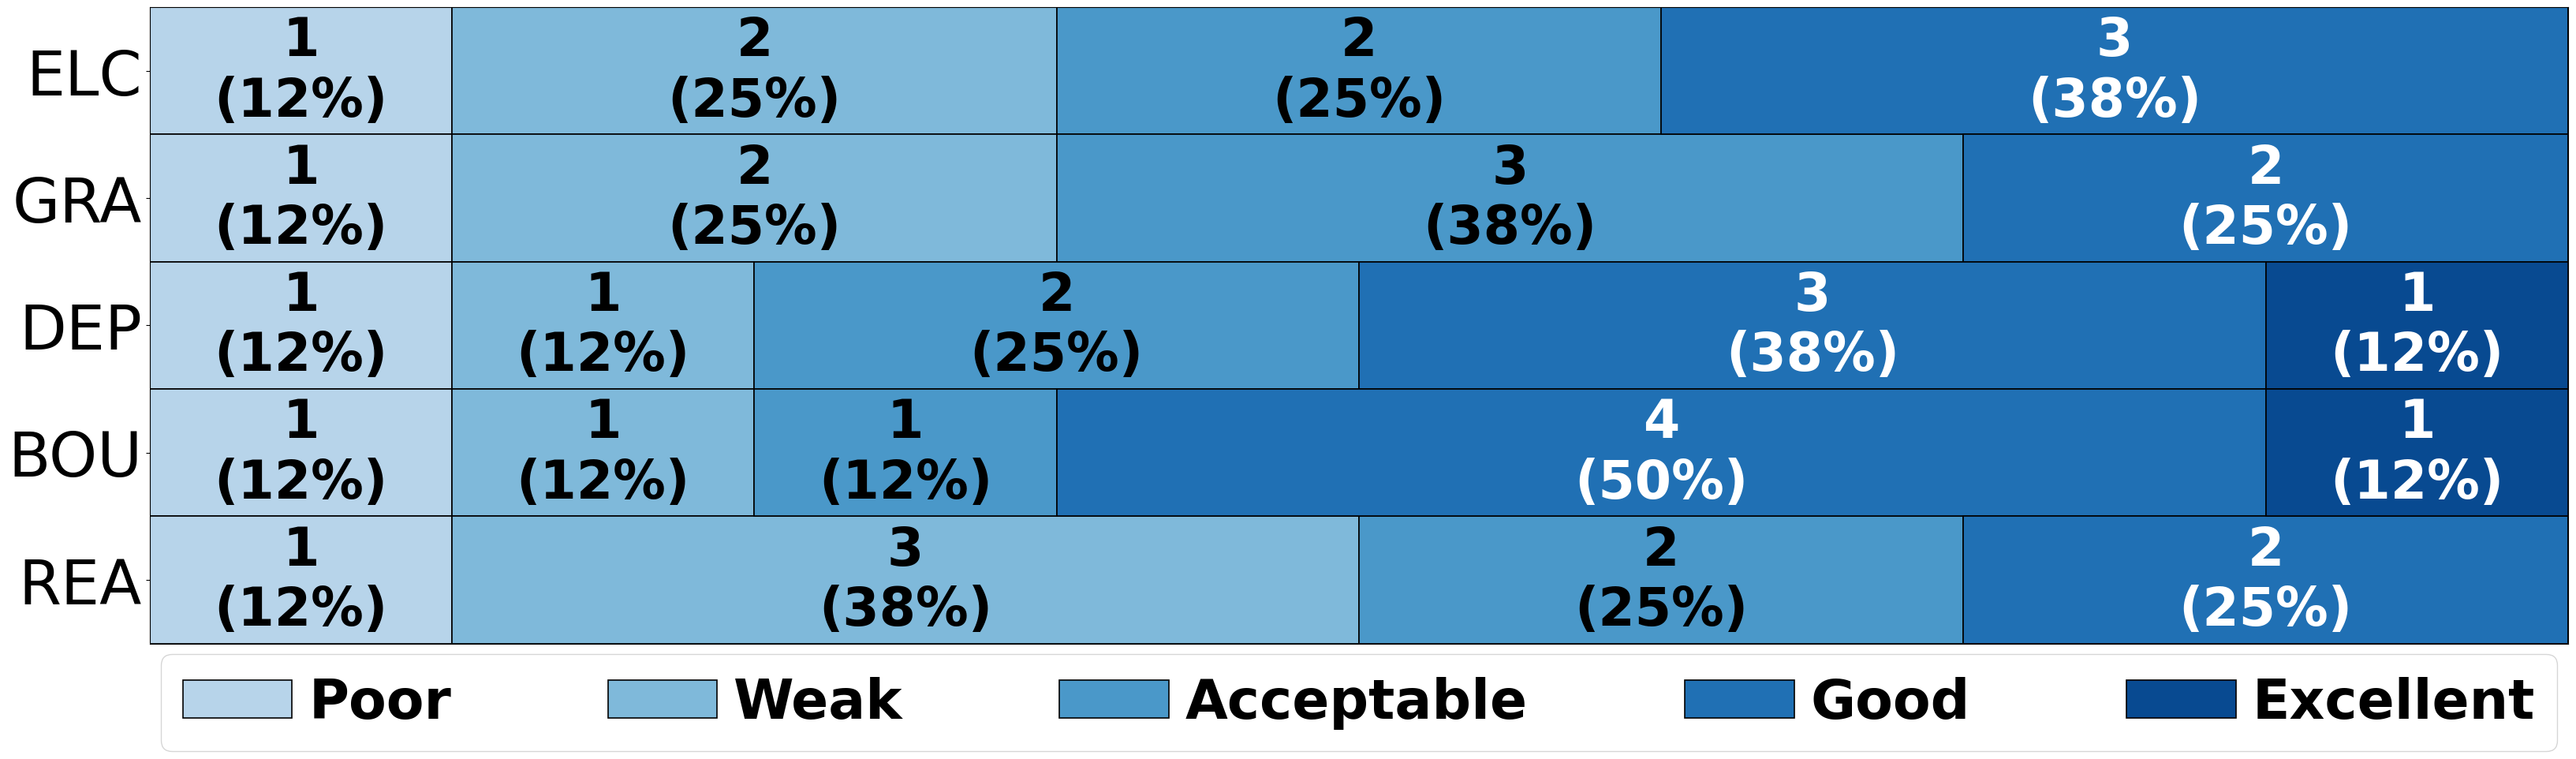

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import re

# ==========================
# LOAD DATA (ChatGPT sheet)
# ==========================
file_path = "Task_4_New.xlsx"  # <- change if needed
df = pd.read_excel(file_path, sheet_name="ChatGPT")

# Clean column names
df.columns = [str(c).strip() for c in df.columns]

# First column = repository identifier (rows = repositories)
first_col = df.columns[0]

# If the sheet has a repeated header row like "ID_Repo" inside the data, drop it
df = df[df[first_col].astype(str).str.strip().str.lower() != "id_repo"].copy()

# Rename first column to "Repo"
df = df.rename(columns={first_col: "Repo"})

# ==========================
# DEFINE YOUR ORDERED SCALE
# (adapt these labels to EXACTLY match your cell values)
# ==========================
category_names = ["Poor", "Weak", "Acceptable", "Good", "Excellent"]

# Wrap legend labels on two lines if needed
wrapped_category_names = [
    "\n".join(textwrap.wrap(name, width=12))
    for name in category_names
]

# ==========================
# SELECT DIMENSIONS (columns)
# ==========================
dimension_cols = [c for c in df.columns if c != "Repo"]

# ==========================
# BUILD RESULTS DICT
# key   = acronym inside parentheses in column name
# value = counts in category order
# ==========================
results = {}
for col in dimension_cols:
    # Extract acronym between parentheses, e.g., "Graphical Readability (GRA)" -> "GRA"
    m = re.search(r"\((.*?)\)", str(col))
    short_label = m.group(1).strip() if m else str(col).strip()

    # Count categories for that dimension across repositories
    counts = (
        df[col]
        .astype(str)
        .str.strip()
        .value_counts()
        .reindex(category_names, fill_value=0)
    )

    results[short_label] = counts.values.tolist()

# ==========================
# GLOBAL FONT SETTINGS (same style)
# ==========================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 56,
    "legend.fontsize": 50
})

# ==========================
# SURVEY PLOT FUNCTION
# ==========================
def survey(results, category_names_wrapped):
    labels = list(results.keys())
    data = np.array(list(results.values()))
    data_cum = data.cumsum(axis=1)
    y = np.arange(len(labels))

    category_colors = plt.colormaps["Blues"](np.linspace(0.3, 0.9, data.shape[1]))
    totals = data.sum(axis=1)

    fig, ax = plt.subplots(figsize=(33, 10))
    plt.subplots_adjust(bottom=0.20)

    ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    ax.set_xlim(0, np.sum(data, axis=1).max())

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.margins(y=0)

    for i, (colname, color) in enumerate(zip(category_names_wrapped, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        perc = np.where(totals > 0, widths / totals * 100, 0)

        rects = ax.barh(
            y, widths, left=starts, height=1,
            label=colname, color=color,
            edgecolor="black", linewidth=1.2
        )

        r, g, b, _ = color
        text_color = "white" if r * g * b < 0.1 else "black"

        bar_labels = [
            f"{int(c)}\n({p:.0f}%)" if c > 0 else ""
            for c, p in zip(widths, perc)
        ]

        for rect, label, p in zip(rects, bar_labels, perc):
            if label == "":
                continue

            fs = 34 if p < 8 else 48

            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + rect.get_height() / 2,
                label,
                ha="center", va="center",
                fontsize=fs,
                color=text_color,
                fontweight="bold"
            )

    ax.legend(
        ncol=len(category_names_wrapped),
        bbox_to_anchor=(0, -0.1, 1, 0.1),
        loc="upper left",
        mode="expand",
        fontsize="large",
        prop={"weight": "bold"},
        columnspacing=0.5,
        handletextpad=0.3,
        borderaxespad=0.2
    )

    return fig, ax

# ==========================
# GENERATE + SAVE FIGURE
# ==========================
fig, ax = survey(results, wrapped_category_names)

plt.tight_layout()
plt.savefig("Task4_ChatGPT_Qualitative_Survey.png", dpi=300)
plt.savefig("Task4_ChatGPT_Qualitative_Survey.pdf", dpi=300)
plt.show()


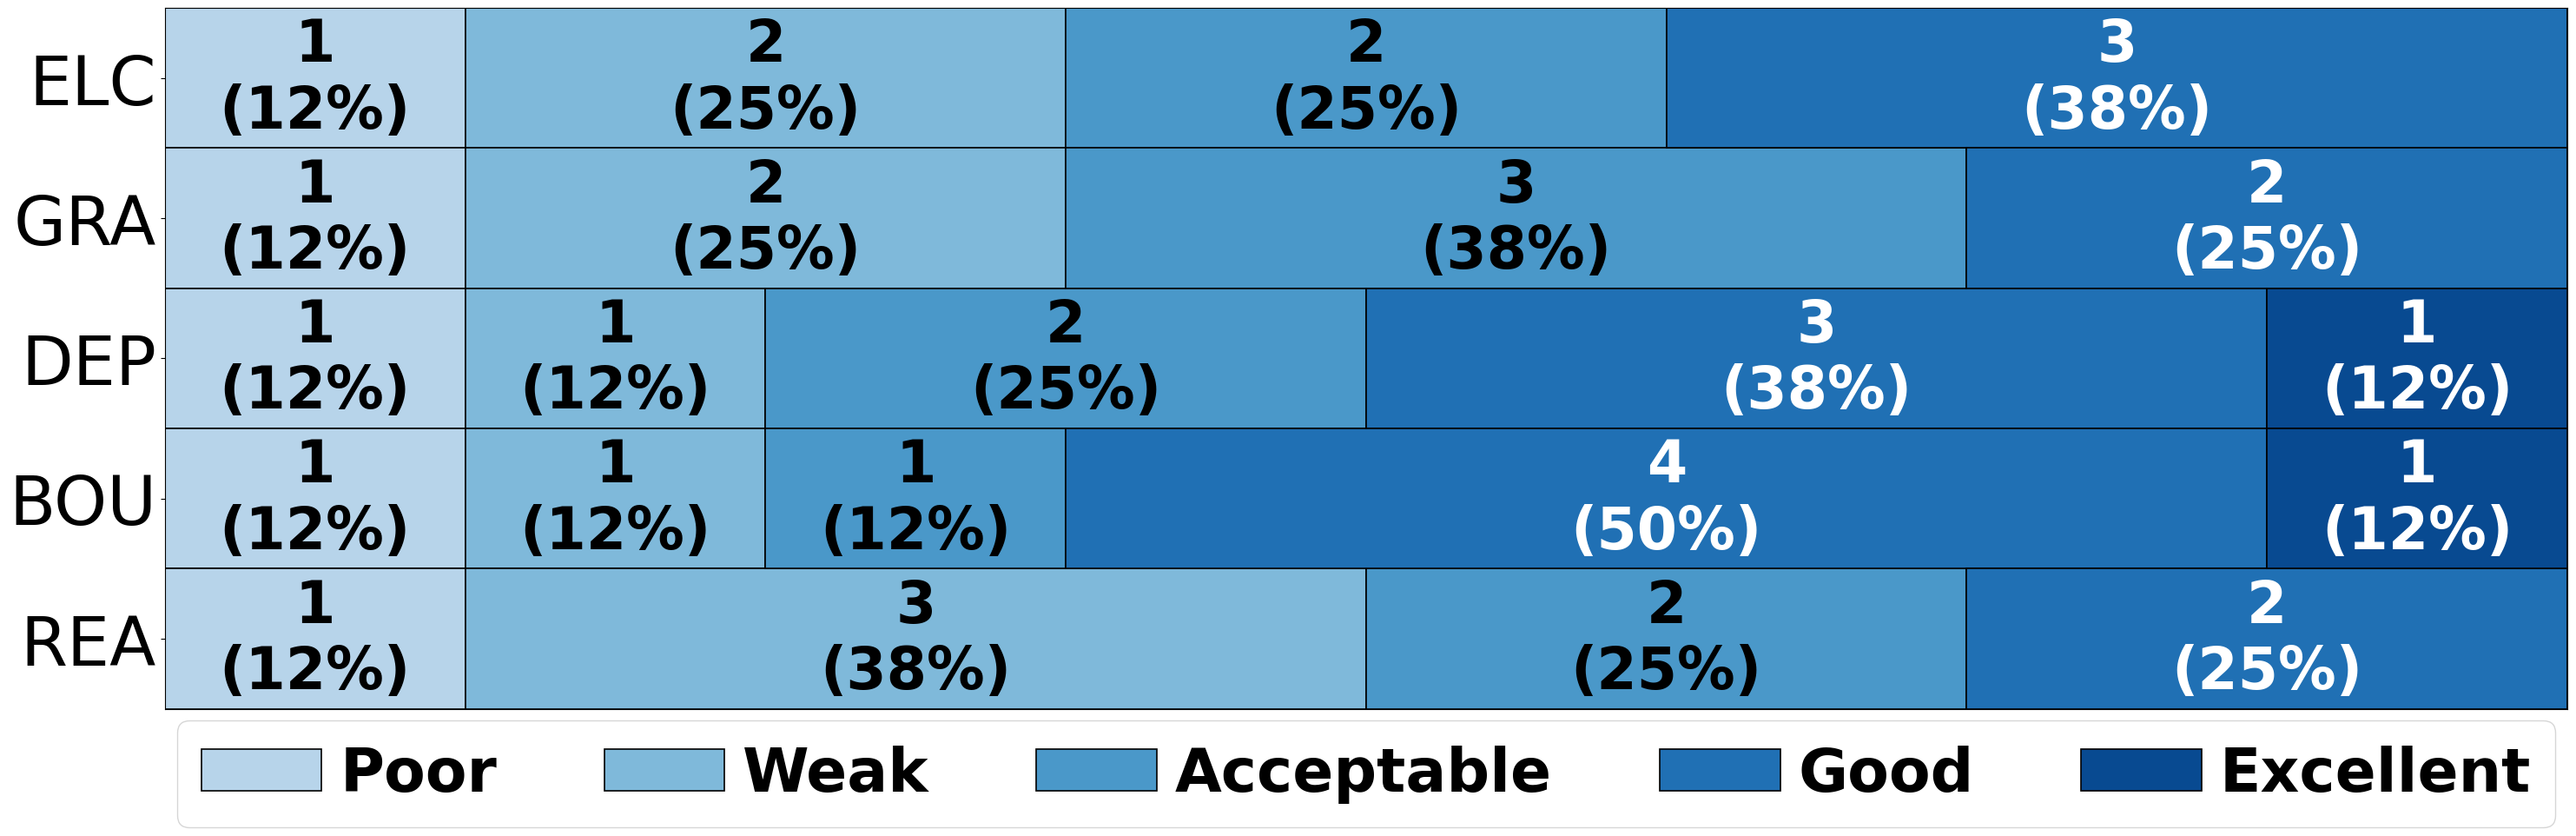

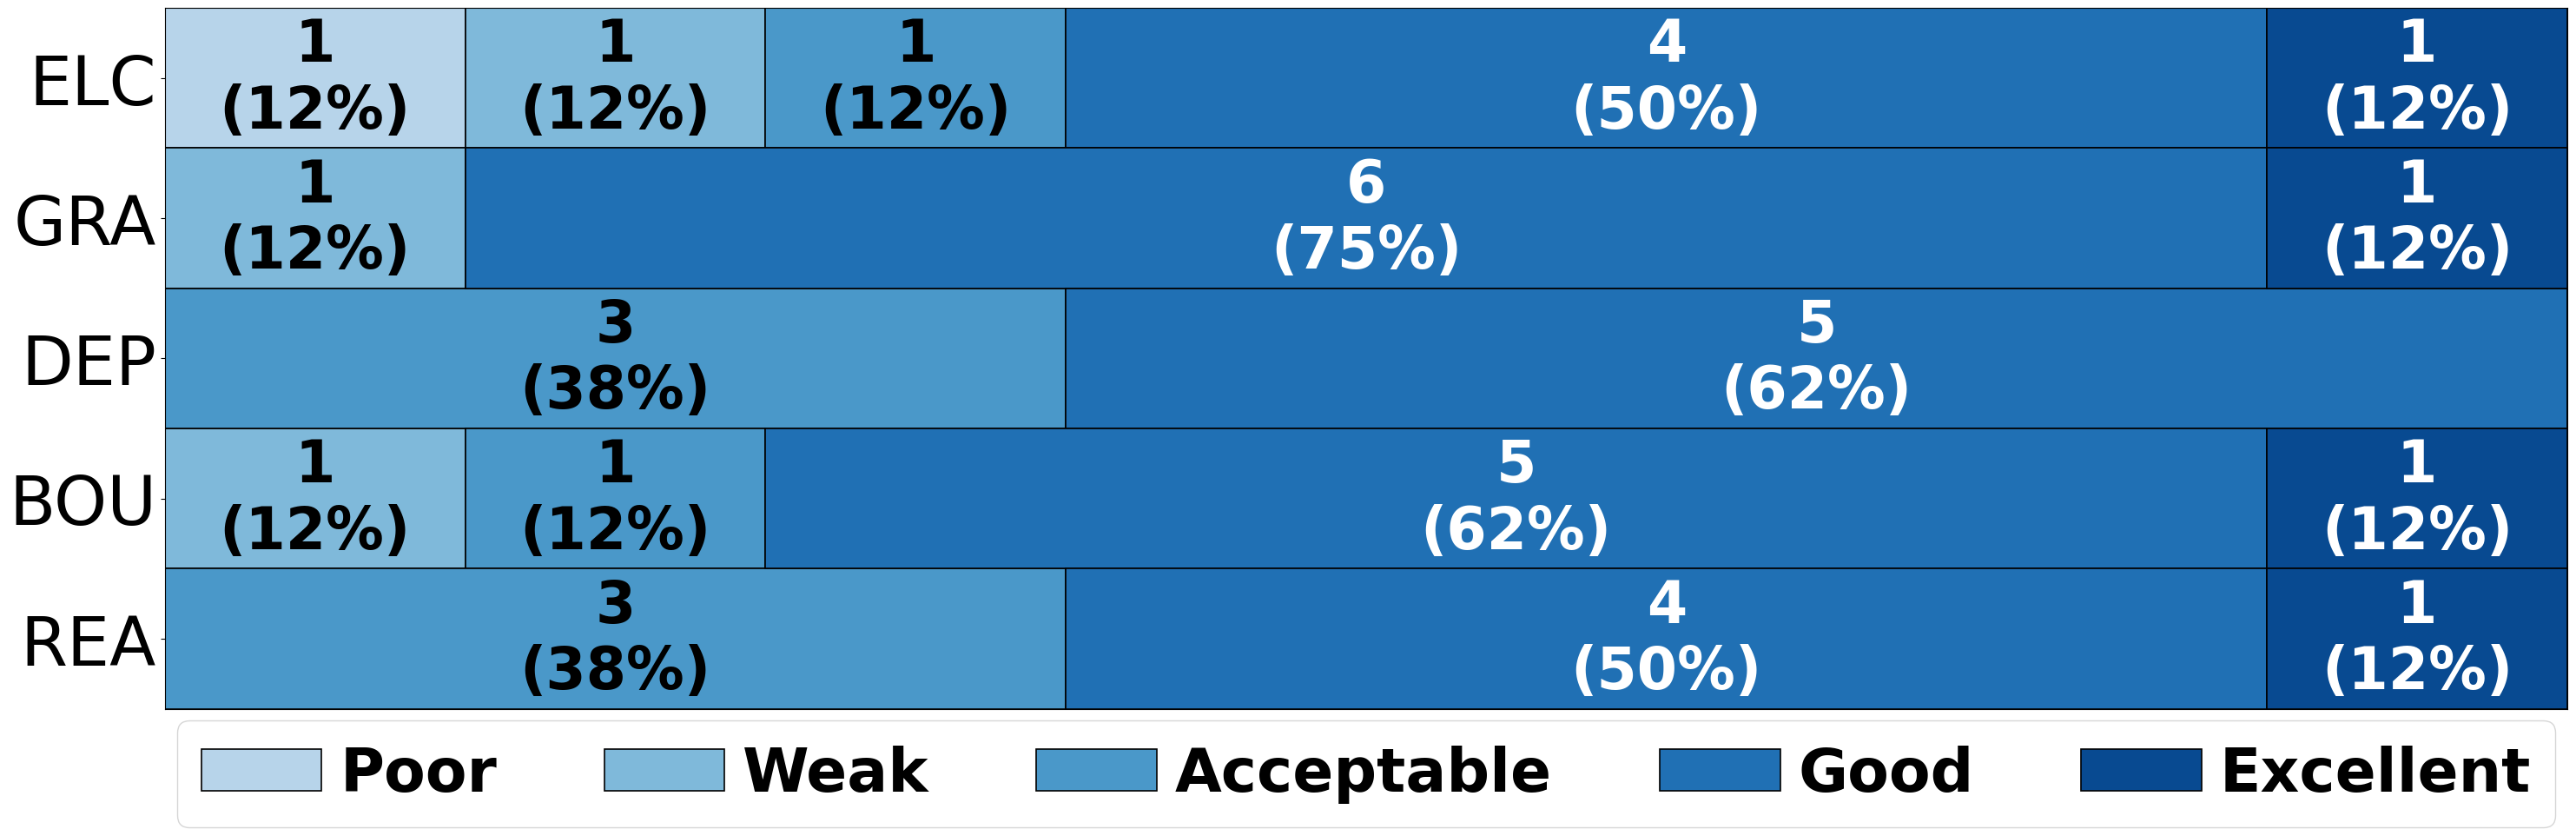

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import re

# ==========================
# CONFIG
# ==========================
file_path = "Task_4_New.xlsx"  # <- change if needed
sheets = ["ChatGPT", "Gemini"]  # generate one plot per sheet

# Define your ordered qualitative scale (must match cell values)
category_names = ["Poor", "Weak", "Acceptable", "Good", "Excellent"]

# Wrap legend labels on two lines if needed
wrapped_category_names = [
    "\n".join(textwrap.wrap(name, width=12))
    for name in category_names
]

# ==========================
# GLOBAL FONT SETTINGS (same style)
# ==========================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 56,
    "legend.fontsize": 50
})

# ==========================
# SURVEY PLOT FUNCTION
# ==========================
def survey(results, category_names_wrapped):
    labels = list(results.keys())
    data = np.array(list(results.values()))
    data_cum = data.cumsum(axis=1)
    y = np.arange(len(labels))

    category_colors = plt.colormaps["Blues"](np.linspace(0.3, 0.9, data.shape[1]))
    totals = data.sum(axis=1)

    fig, ax = plt.subplots(figsize=(30, 10))
    plt.subplots_adjust(bottom=0.20)

    ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    ax.set_xlim(0, np.sum(data, axis=1).max())

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.margins(y=0)

    for i, (colname, color) in enumerate(zip(category_names_wrapped, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        perc = np.where(totals > 0, widths / totals * 100, 0)

        rects = ax.barh(
            y, widths, left=starts, height=1,
            label=colname, color=color,
            edgecolor="black", linewidth=1.2
        )

        r, g, b, _ = color
        text_color = "white" if r * g * b < 0.1 else "black"

        bar_labels = [
            f"{int(c)}\n({p:.0f}%)" if c > 0 else ""
            for c, p in zip(widths, perc)
        ]

        for rect, label, p in zip(rects, bar_labels, perc):
            if label == "":
                continue

            fs = 34 if p < 8 else 48

            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + rect.get_height() / 2,
                label,
                ha="center", va="center",
                fontsize=fs,
                color=text_color,
                fontweight="bold"
            )

    ax.legend(
        ncol=len(category_names_wrapped),
        bbox_to_anchor=(0, -0.1, 1, 0.1),
        loc="upper left",
        mode="expand",
        fontsize="large",
        prop={"weight": "bold"},
        columnspacing=0.5,
        handletextpad=0.3,
        borderaxespad=0.2
    )

    return fig, ax

# ==========================
# MAIN: GENERATE ONE PLOT PER SHEET
# ==========================
for sheet_name in sheets:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    df.columns = [str(c).strip() for c in df.columns]

    # First column = repository identifier
    first_col = df.columns[0]

    # Drop any repeated header row inside the data (common in manual exports)
    df = df[df[first_col].astype(str).str.strip().str.lower() != "id_repo"].copy()

    # Rename first column to "Repo"
    df = df.rename(columns={first_col: "Repo"})

    # Dimension columns = all except repo id
    dimension_cols = [c for c in df.columns if c != "Repo"]

    # Build results: acronym in parentheses as label
    results = {}
    for col in dimension_cols:
        m = re.search(r"\((.*?)\)", str(col))
        short_label = m.group(1).strip() if m else str(col).strip()

        counts = (
            df[col]
            .astype(str)
            .str.strip()
            .value_counts()
            .reindex(category_names, fill_value=0)
        )
        results[short_label] = counts.values.tolist()

    # Plot
    fig, ax = survey(results, wrapped_category_names)

    plt.tight_layout()
    plt.savefig(f"Task4_{sheet_name}_Qualitative_Survey.png", dpi=300)
    plt.savefig(f"Task4_{sheet_name}_Qualitative_Survey.pdf", dpi=300)

    plt.show()
    plt.close(fig)
